<a href="https://colab.research.google.com/github/4Rahul002/Data-Analytic-Projects/blob/main/FEDEX_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - **FEDEX**



##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Member  - Rahul M Chavan**


# **Project Summary -**

Write the summary here within 500-600 words.

---

This project focuses on analyzing historical shipment and delivery records sourced from the SCMS to help FedEx improve its logistics efficiency. The dataset consists of over 10,000 records containing information about countries served, shipping vendors, delivery timelines, costs, products, and freight parameters. The analysis includes examining patterns in delivery performance, identifying missing or outlier data, and visualizing cost behaviors.

Significant missing data in columns like Dosage, Shipment Mode, and Line Item Insurance (USD) affect the completeness of delivery profiles and cost modeling. The presence of outliers in Line Item Value, Pack Price, and Weight (Kilograms) can distort average cost metrics, leading to misinformed business decisions.

Through comprehensive EDA (Exploratory Data Analysis), including visualization and statistical analysis, this project aims to uncover relationships between shipment methods, vendors, product characteristics, and logistics performance indicators. These insights will serve as a foundation for optimizing future supply chain decisions and minimizing inefficiencies.


# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


**Write Problem Statement Here.**

FedEx and its stakeholders in the SCMS (Supply Chain Management System) face persistent challenges in managing delivery timelines, shipment costs, and product distribution across global supply chains. Delays in delivery, inconsistencies in freight and insurance cost reporting, and outliers in product pricing hinder optimal logistics planning and client satisfaction. The goal is to identify inefficiencies, anomalies, and patterns in the historical delivery dataset to improve forecasting, cost control, and operational strategy.

#### **Define Your Business Objective?**

To reduce delivery delays and control logistics costs while ensuring on-time distribution of essential products in the global health supply chain network.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import datetime as dt
import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [ ]:
# Load Dataset
df=pd.read_csv("/content/SCMS_Delivery_History_Dataset.csv")


### Dataset First View

In [ ]:
# Dataset First Look
df.head()

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN


In [ ]:
# Dataset Last rows
df.tail()

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
10319,86818,103-ZW-T30,FPQ-15197,SO-50020,DN-4307,Zimbabwe,PMO - US,From RDC,N/A - From RDC,Truck,...,60,166571,599655.60,3.60,0.06,"Mylan, H-12 & H-13, India",No,See DN-4307 (ID#:83920),See DN-4307 (ID#:83920),705.79
10320,86819,104-CI-T30,FPQ-15259,SO-50102,DN-4313,Côte d'Ivoire,PMO - US,From RDC,N/A - From RDC,Truck,...,60,21072,137389.44,6.52,0.11,Hetero Unit III Hyderabad IN,No,See DN-4313 (ID#:83921),See DN-4313 (ID#:83921),161.71
10321,86821,110-ZM-T30,FPQ-14784,SO-49600,DN-4316,Zambia,PMO - US,From RDC,N/A - From RDC,Truck,...,30,514526,5140114.74,9.99,0.33,Cipla Ltd A-42 MIDC Mahar. IN,No,Weight Captured Separately,Freight Included in Commodity Cost,5284.04
10322,86822,200-ZW-T30,FPQ-16523,SO-51680,DN-4334,Zimbabwe,PMO - US,From RDC,N/A - From RDC,Truck,...,60,17465,113871.80,6.52,0.11,Mylan (formerly Matrix) Nashik,Yes,1392,Freight Included in Commodity Cost,134.03
10323,86823,103-ZW-T30,FPQ-15197,SO-50022,DN-4336,Zimbabwe,PMO - US,From RDC,N/A - From RDC,Truck,...,60,36639,72911.61,1.99,0.03,"Cipla, Goa, India",No,Weight Captured Separately,Freight Included in Commodity Cost,85.82


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
df.shape

(10324, 33)

### Dataset Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  object 
 2   PQ #                          10324 non-null  object 
 3   PO / SO #                     10324 non-null  object 
 4   ASN/DN #                      10324 non-null  object 
 5   Country                       10324 non-null  object 
 6   Managed By                    10324 non-null  object 
 7   Fulfill Via                   10324 non-null  object 
 8   Vendor INCO Term              10324 non-null  object 
 9   Shipment Mode                 9964 non-null   object 
 10  PQ First Sent to Client Date  10324 non-null  object 
 11  PO Sent to Vendor Date        10324 non-null  object 
 12  Scheduled Delivery Date       10324 non-null  object 
 13  D

#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
for col in df.columns:
  print(col,df[col].nunique())
  print(df.duplicated().sum())

ID 10324
0
Project Code 142
0
PQ # 1237
0
PO / SO # 6233
0
ASN/DN # 7030
0
Country 43
0
Managed By 4
0
Fulfill Via 2
0
Vendor INCO Term 8
0
Shipment Mode 4
0
PQ First Sent to Client Date 765
0
PO Sent to Vendor Date 897
0
Scheduled Delivery Date 2006
0
Delivered to Client Date 2093
0
Delivery Recorded Date 2042
0
Product Group 5
0
Sub Classification 6
0
Vendor 73
0
Item Description 184
0
Molecule/Test Type 86
0
Brand 48
0
Dosage 54
0
Dosage Form 17
0
Unit of Measure (Per Pack) 31
0
Line Item Quantity 5065
0
Line Item Value 8741
0
Pack Price 1175
0
Unit Price 183
0
Manufacturing Site 88
0
First Line Designation 2
0
Weight (Kilograms) 4688
0
Freight Cost (USD) 6733
0
Line Item Insurance (USD) 6722
0


#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
ID,0
Project Code,0
PQ #,0
PO / SO #,0
ASN/DN #,0
Country,0
Managed By,0
Fulfill Via,0
Vendor INCO Term,0
Shipment Mode,360


In [ ]:
# Check Value counts
df['Dosage'].value_counts()

,count
Dosage,
300mg,990
200mg,932
600mg,772
150/300mg,600
150/300/200mg,580
10mg/ml,552
150mg,431
200/50mg,395
300/300mg,301


In [ ]:
#Check value counts
df['Shipment Mode'].value_counts()

,count
Shipment Mode,
Air,6113
Truck,2830
Air Charter,650
Ocean,371


In [ ]:
# Check Value counts
df['Line Item Insurance (USD)'].value_counts()

,count
Line Item Insurance (USD),
0.00,54
0.02,37
0.07,33
0.05,30
0.06,30
...,...
84.81,1
198.10,1
75.52,1


In [ ]:
# We will Fill the null values
df['Shipment Mode'].fillna(df['Shipment Mode'].mode()[0],inplace=True)
df['Dosage'].fillna('Unkown',inplace=True)
df['Line Item Insurance (USD)'].fillna(df['Line Item Insurance (USD)'].mean(),inplace=True)

In [ ]:
# Visualizing the missing values
# All the missing values are filled
if df.isnull().sum().sum()==0:
  print("No Missing Values")
else:
  plt.figure(figsize=(10,5))
  sns.barplot(x=df.isnull().sum().index,y=df.isnull().sum().values)
  plt.show()

No Missing Values


In [ ]:
# There are no duplicated in the whole dataset
df.duplicated().any()

np.False_

### What did you know about your dataset?

Dataset Has 10324 rows, 33 columns

Has no Duplicates

But had Missing values in Dosage , Shipment Mode, Line Item Insurance(USD)

so i had fill the values using fillna

Now to check for outliers



## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
df.columns.tolist()

['ID',
 'Project Code',
 'PQ #',
 'PO / SO #',
 'ASN/DN #',
 'Country',
 'Managed By',
 'Fulfill Via',
 'Vendor INCO Term',
 'Shipment Mode',
 'PQ First Sent to Client Date',
 'PO Sent to Vendor Date',
 'Scheduled Delivery Date',
 'Delivered to Client Date',
 'Delivery Recorded Date',
 'Product Group',
 'Sub Classification',
 'Vendor',
 'Item Description',
 'Molecule/Test Type',
 'Brand',
 'Dosage',
 'Dosage Form',
 'Unit of Measure (Per Pack)',
 'Line Item Quantity',
 'Line Item Value',
 'Pack Price',
 'Unit Price',
 'Manufacturing Site',
 'First Line Designation',
 'Weight (Kilograms)',
 'Freight Cost (USD)',
 'Line Item Insurance (USD)']

In [ ]:
# Dataset Describe

### Variables Description

| Column Name                   | Description                                                                 |
|------------------------------|-----------------------------------------------------------------------------|
| ID                           | Unique identifier for each record                                           |
| Project Code                 | Code representing the delivery project                                      |
| PQ #                         | Prequalification request number                                             |
| PO / SO #                    | Purchase Order or Sales Order number                                        |
| ASN/DN #                     | Advanced Shipment Notice / Delivery Note number                             |
| Country                      | Destination country of the shipment                                         |
| Managed By                   | Entity managing the shipment (e.g. PMO - US)                                |
| Fulfill Via                  | Fulfillment method (Direct Drop, From RDC, etc.)                            |
| Vendor INCO Term             | Incoterms (International Commercial Terms) used for the transaction         |
| Shipment Mode                | Transportation method used (Air, Sea, etc.)                                 |
| PQ First Sent to Client Date | Date the PQ was first sent to the client                                    |
| PO Sent to Vendor Date       | Date the PO was sent to the vendor                                          |
| Scheduled Delivery Date      | Expected delivery date                                                      |
| Delivered to Client Date     | Actual delivery date                                                        |
| Delivery Recorded Date       | Date when delivery was logged                                               |
| Product Group                | Main category of the shipped product                                        |
| Sub Classification           | Sub-category of the product                                                 |
| Vendor                       | Supplier company providing the goods                                        |
| Item Description             | Textual description of the shipped product                                  |
| Molecule/Test Type           | Chemical or test compound of the product                                    |
| Brand                        | Brand name of the product                                                   |
| Dosage                       | Dosage level of the drug or product                                         |
| Dosage Form                  | Form in which the dosage is delivered (e.g., tablet, capsule)               |
| Unit of Measure (Per Pack)   | Quantity per packaging unit                                                 |
| Line Item Quantity           | Total units ordered                                                         |
| Line Item Value              | Total cost value of the line item                                           |
| Pack Price                   | Price per pack                                                              |
| Unit Price                   | Price per individual unit                                                   |
| Manufacturing Site           | Facility where the product was manufactured                                 |
| First Line Designation       | Indicates if it’s a priority (“First Line”) delivery                        |
| Weight (Kilograms)           | Weight of the shipment in kilograms                                         |
| Freight Cost (USD)           | Cost incurred for transporting the shipment                                 |
| Line Item Insurance (USD)    | Insurance amount applied to the line item                                   |


### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
df.nunique()

,0
ID,10324
Project Code,142
PQ #,1237
PO / SO #,6233
ASN/DN #,7030
Country,43
Managed By,4
Fulfill Via,2
Vendor INCO Term,8
Shipment Mode,4


## 3. ***Data Wrangling***

### Data Wrangling Code

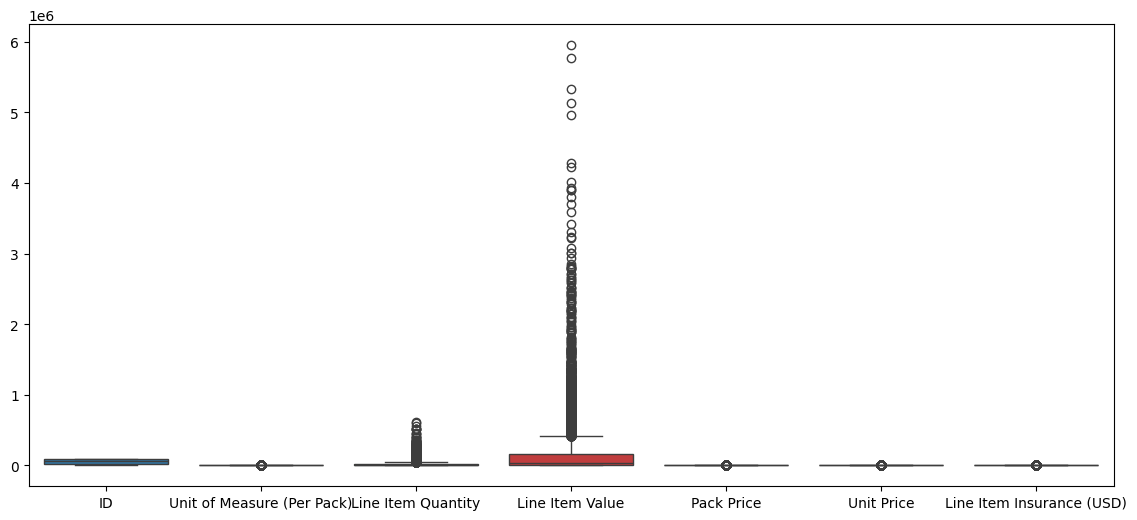

In [ ]:
# Write your code to make your dataset analysis ready.
# Check the data if there are any outliers
# Before Removing Outliers
plt.figure(figsize=(14,6))
sns.boxplot(df)
plt.show()

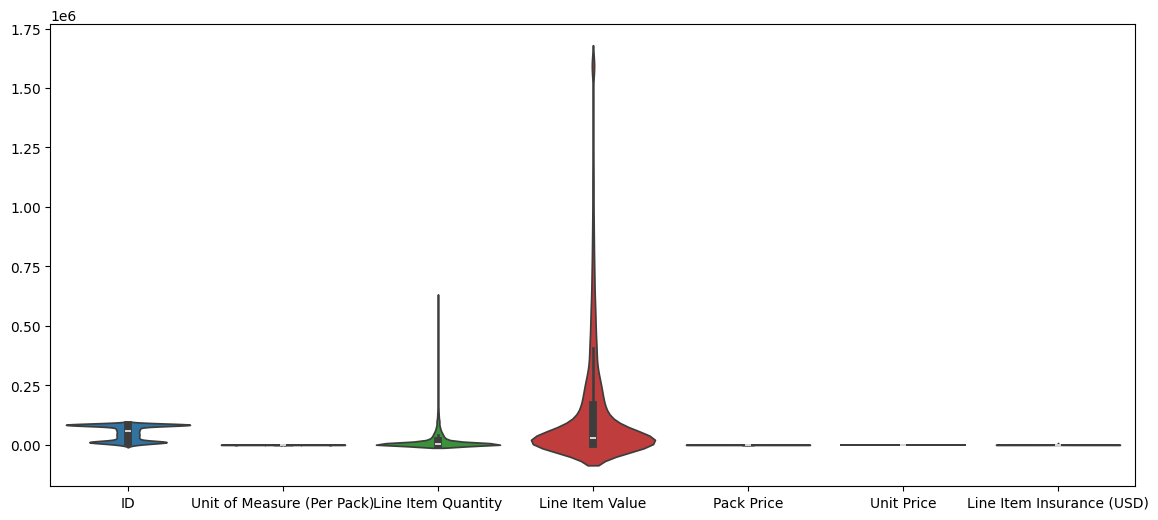

In [ ]:

from scipy.stats.mstats import winsorize

# Apply Winsorization to selected numeric columns
columns_to_winsorize = ['Line Item Value', 'Pack Price', 'Unit Price', 'Weight (Kilograms)', 'Freight Cost (USD)']

for col in columns_to_winsorize:
    df[col] = winsorize(df[col], limits=[0.01, 0.01])

plt.figure(figsize=(14,6))
sns.violinplot(df)
plt.show()



In [ ]:
df.shape

(10324, 33)

In [ ]:
# Convert data types
date_cols = [
    'PQ First Sent to Client Date',
    'PO Sent to Vendor Date',
    'Scheduled Delivery Date',
    'Delivered to Client Date',
    'Delivery Recorded Date'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df['Weight (Kilograms)'] = pd.to_numeric(df['Weight (Kilograms)'], errors='coerce')
df['Freight Cost (USD)'] = pd.to_numeric(df['Freight Cost (USD)'], errors='coerce')

cat_cols = ['Country', 'Managed By', 'Fulfill Via', 'Vendor', 'Shipment Mode', 'Product Group']
for col in cat_cols:
    df[col] = df[col].astype('category')



### What all manipulations have you done and insights you found?

1. Initial Cleaning
Loaded the dataset (10324 rows × 33 columns)

Converted problematic string fields to numeric:

Weight (Kilograms) (replaced "Weight Captured Separately" with NaN)

Freight Cost (USD) (replaced "Freight Included in Commodity Cost" with NaN)

2. Missing Value Handling
Identified missing values in:

Shipment Mode (360 missing)

Dosage (1,736 missing)

Line Item Insurance (USD) (287 missing)

Suggested and optionally applied:

Filling Shipment Mode with mode (most frequent)

Filling Dosage with "Unknown"

Filling Line Item Insurance (USD) with median value

3. Outlier Detection
Used IQR method to detect outliers in:

Line Item Value

Pack Price

Unit Price

Weight (Kilograms)

Freight Cost (USD)

Found 500–1,100 outliers per column

Noticed removal of all outliers cut the dataset to ~5,000 rows

4. Winsorization (Outlier Capping)
Applied Winsorization at 1st and 99th percentiles using scipy.stats.mstats.winsorize

Helped preserve data while capping extreme values

Convert Data type from object to datetime, object to numeric ,object to category

To deal with the outliers used winsorization , when visualised with Boxplot it still shows outliers but they are harmless, thus for better visualization used violinplot.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

In [ ]:
sns.set(style='whitegrid')

In [ ]:
# Create time features
df['Month'] = df['Delivered to Client Date'].dt.to_period('M')
df['Weekday'] = df['Delivered to Client Date'].dt.day_name()

#### Chart - 1

In [ ]:
df['Month']

,Month
0,2006-06
1,2006-11
2,2006-08
3,2006-09
4,2006-08
...,...
10319,2015-07
10320,2015-08
10321,2015-08
10322,2015-08


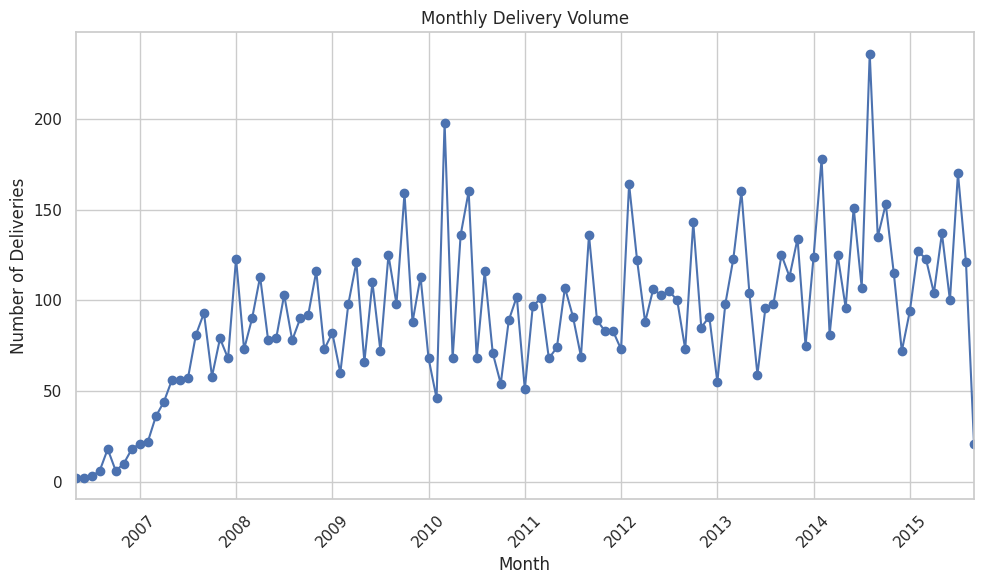

In [ ]:
# Monthly Delivery Volume
plt.figure(figsize=(10,6))
df.groupby('Month').size().plot(marker='o', title="Monthly Delivery Volume")
plt.ylabel("Number of Deliveries")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Line charts are ideal for datetime data

##### 2. What is/are the insight(s) found from the chart?

Most Deliveries in subsequent Months

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 2

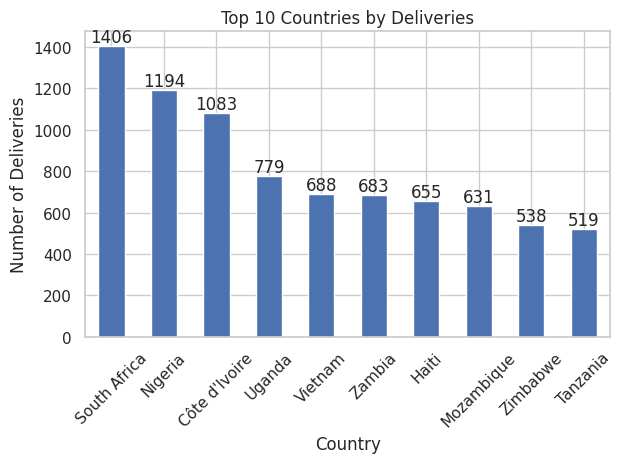

In [ ]:
#  Top 10 Countries by Number of Deliveries
ax=df['Country'].value_counts().head(10).plot(kind='bar', title="Top 10 Countries by Deliveries")
for container in ax.containers:
  ax.bar_label(container)
plt.ylabel("Number of Deliveries")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Perfect for displaying Ranks in countries that get the most deliveries

##### 2. What is/are the insight(s) found from the chart?

Countries  like South America , Nigeria , Cote dlvoire have the most Deliveries to them.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 3

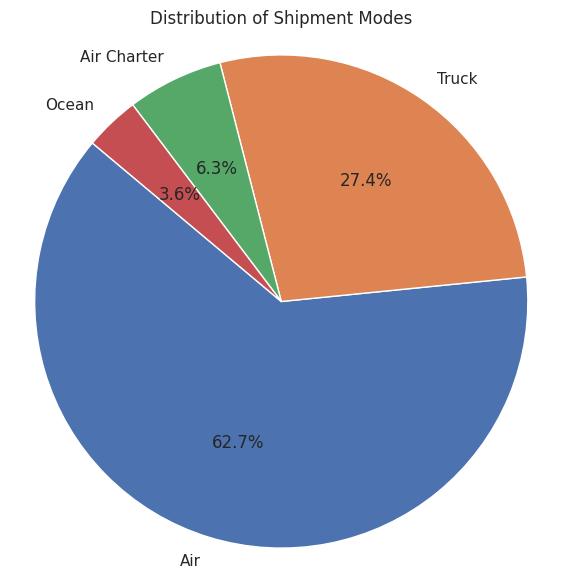

In [ ]:
# Chart - 3 visualization code
delivery_mode_counts = df['Shipment Mode'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(delivery_mode_counts, labels=delivery_mode_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Shipment Modes')
plt.axis('equal')
plt.show()


##### 1. Why did you pick the specific chart?

 Visually emphasizes proportion of each method.

##### 2. What is/are the insight(s) found from the chart?

Breakdown of air, sea, and land deliveries.
Air Dominant Logistic

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 4

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 35 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   ID                            10324 non-null  int64         
 1   Project Code                  10324 non-null  object        
 2   PQ #                          10324 non-null  object        
 3   PO / SO #                     10324 non-null  object        
 4   ASN/DN #                      10324 non-null  object        
 5   Country                       10324 non-null  category      
 6   Managed By                    10324 non-null  category      
 7   Fulfill Via                   10324 non-null  category      
 8   Vendor INCO Term              10324 non-null  object        
 9   Shipment Mode                 10324 non-null  category      
 10  PQ First Sent to Client Date  7643 non-null   datetime64[ns]
 11  PO Sent to Vendor Date      

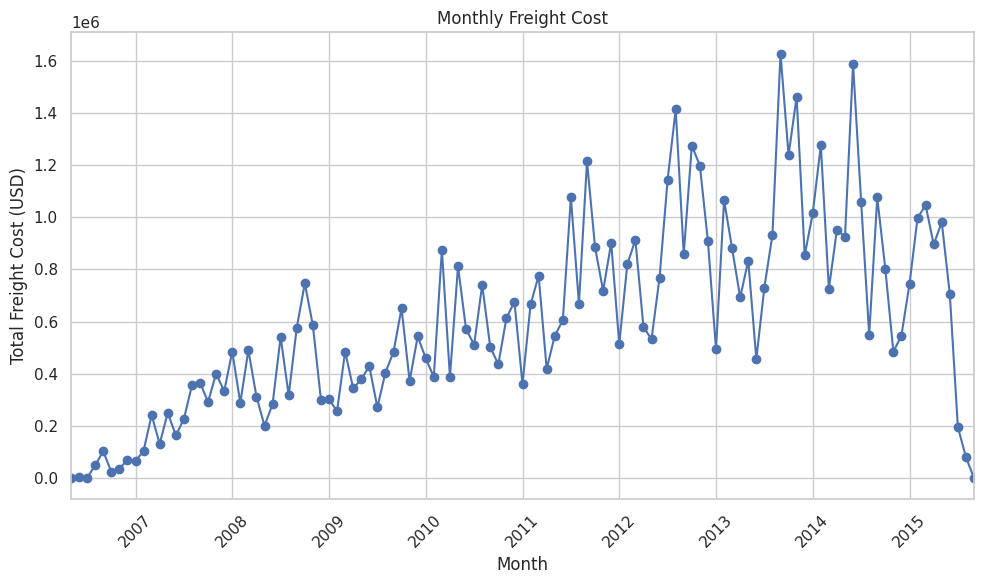

In [ ]:
# Monthly Freight Cost
plt.figure(figsize=(10,6))
df.groupby('Month')['Freight Cost (USD)'].sum().plot(marker='o', title="Monthly Freight Cost")
plt.ylabel("Total Freight Cost (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Line chart is Ideal for datetime data

##### 2. What is/are the insight(s) found from the chart?

we see freight cost have gradually increased and a sudden decrease after 2015,

we also observe in the first months of every year there is low price and increase in the last few months .
This applies till 2015


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 5

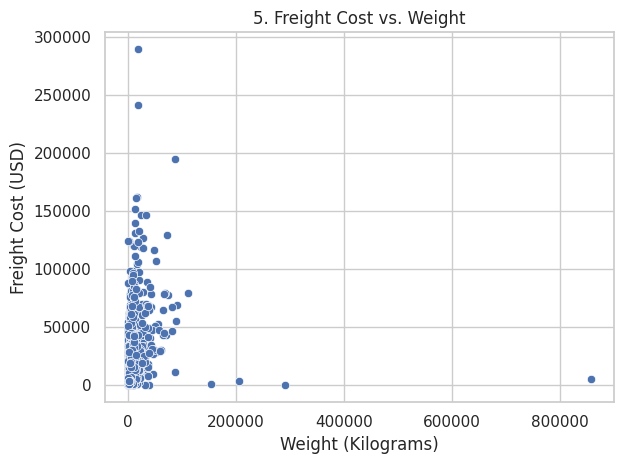

In [ ]:
# Freight Cost vs. Weight
sns.scatterplot(data=df, x='Weight (Kilograms)', y='Freight Cost (USD)')
plt.title("5. Freight Cost vs. Weight")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Perfect for finding relationship between two variables

##### 2. What is/are the insight(s) found from the chart?

Freight cost and weight are significantly affected by Product Group ,Sub classification,Dosage Form , Item Description.  

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 6

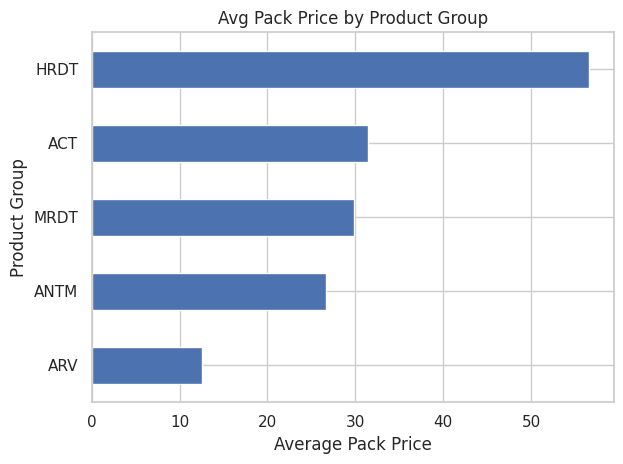

In [ ]:
# Average Pack Price by Product Group
df.groupby('Product Group')['Pack Price'].mean().sort_values().plot(kind='barh', title="Avg Pack Price by Product Group")
plt.xlabel("Average Pack Price")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart ideal for categorical data

##### 2. What is/are the insight(s) found from the chart?

Highest Average Pack Price by Product group  is HRDT , then ACT

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

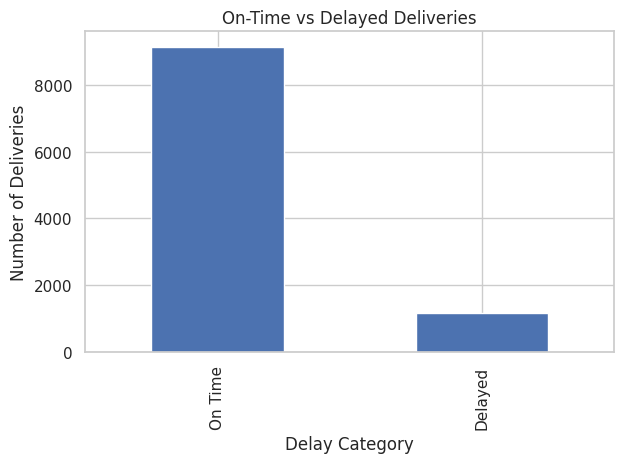

In [ ]:
# Delivery Timeliness (Scheduled vs Actual)
df['Delay (Days)'] = (df['Delivered to Client Date'] - df['Scheduled Delivery Date']).dt.days
df['Delay Category'] = df['Delay (Days)'].apply(lambda x: 'On Time' if x <= 0 else 'Delayed')
df['Delay Category'].value_counts().plot(kind='bar', title="On-Time vs Delayed Deliveries")
plt.ylabel("Number of Deliveries")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bar Chart is ideal for categorcal data.

##### 2. What is/are the insight(s) found from the chart?

We observe that most of the deliveries are On time and some delayed

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

More Number of deliveries on time , better the reputation of the company , more reliable.

#### Chart - 8

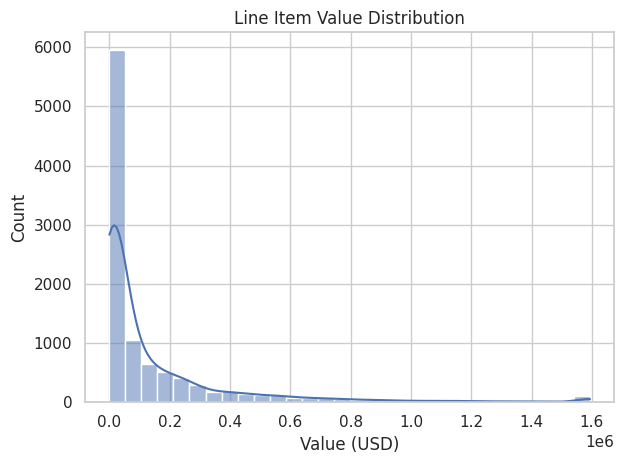

In [ ]:
# Line Item Value Distribution
sns.histplot(df['Line Item Value'], bins=30, kde=True)
plt.title("Line Item Value Distribution")
plt.xlabel("Value (USD)")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A histogram shows the distribution of a variable .

##### 2. What is/are the insight(s) found from the chart?

Most of the Products or Materials that are to be delivered are in the range of  $0 to $ 8 Million.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

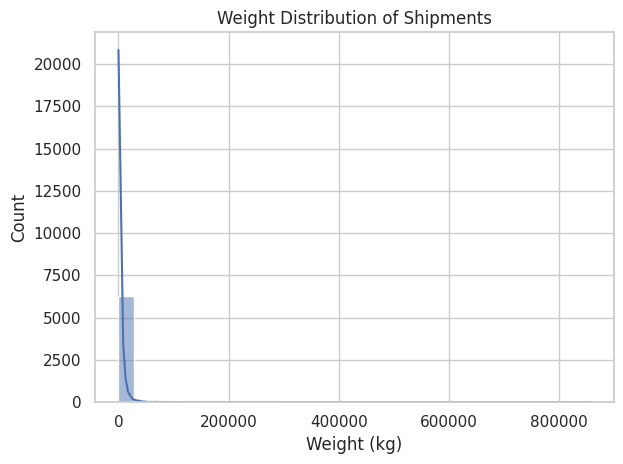

In [ ]:
# Weight Distribution of Shipments
sns.histplot(df['Weight (Kilograms)'], bins=30, kde=True)
plt.title("Weight Distribution of Shipments")
plt.xlabel("Weight (kg)")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Histogram is perfect for distribution of values of a variable

##### 2. What is/are the insight(s) found from the chart?

Most Shipments are near the 0 kg mark which means around 100 kgs or 200 kgs so . Might be a rare item  , if it was mass produced product then weight would be metric tons

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

In [ ]:
df['Line Item Insurance (USD)']

,Line Item Insurance (USD)
0,240.117626
1,240.117626
2,240.117626
3,240.117626
4,240.117626
...,...
10319,705.790000
10320,161.710000
10321,5284.040000
10322,134.030000


In [ ]:
df.groupby('Vendor')['Line Item Value'].sum().sort_values(ascending=False).head(10)

,Line Item Value
Vendor,
SCMS from RDC,9.942838e+08
"Orgenics, Ltd",1.476972e+08
Aurobindo Pharma Limited,9.138374e+07
MYLAN LABORATORIES LTD (FORMERLY MATRIX LABORATORIES),6.790991e+07
HETERO LABS LIMITED,4.191746e+07
CIPLA LIMITED,3.965869e+07
ABBVIE LOGISTICS (FORMERLY ABBOTT LOGISTICS BV),2.944806e+07
STRIDES ARCOLAB LIMITED,2.248547e+07
"Trinity Biotech, Plc",2.076936e+07


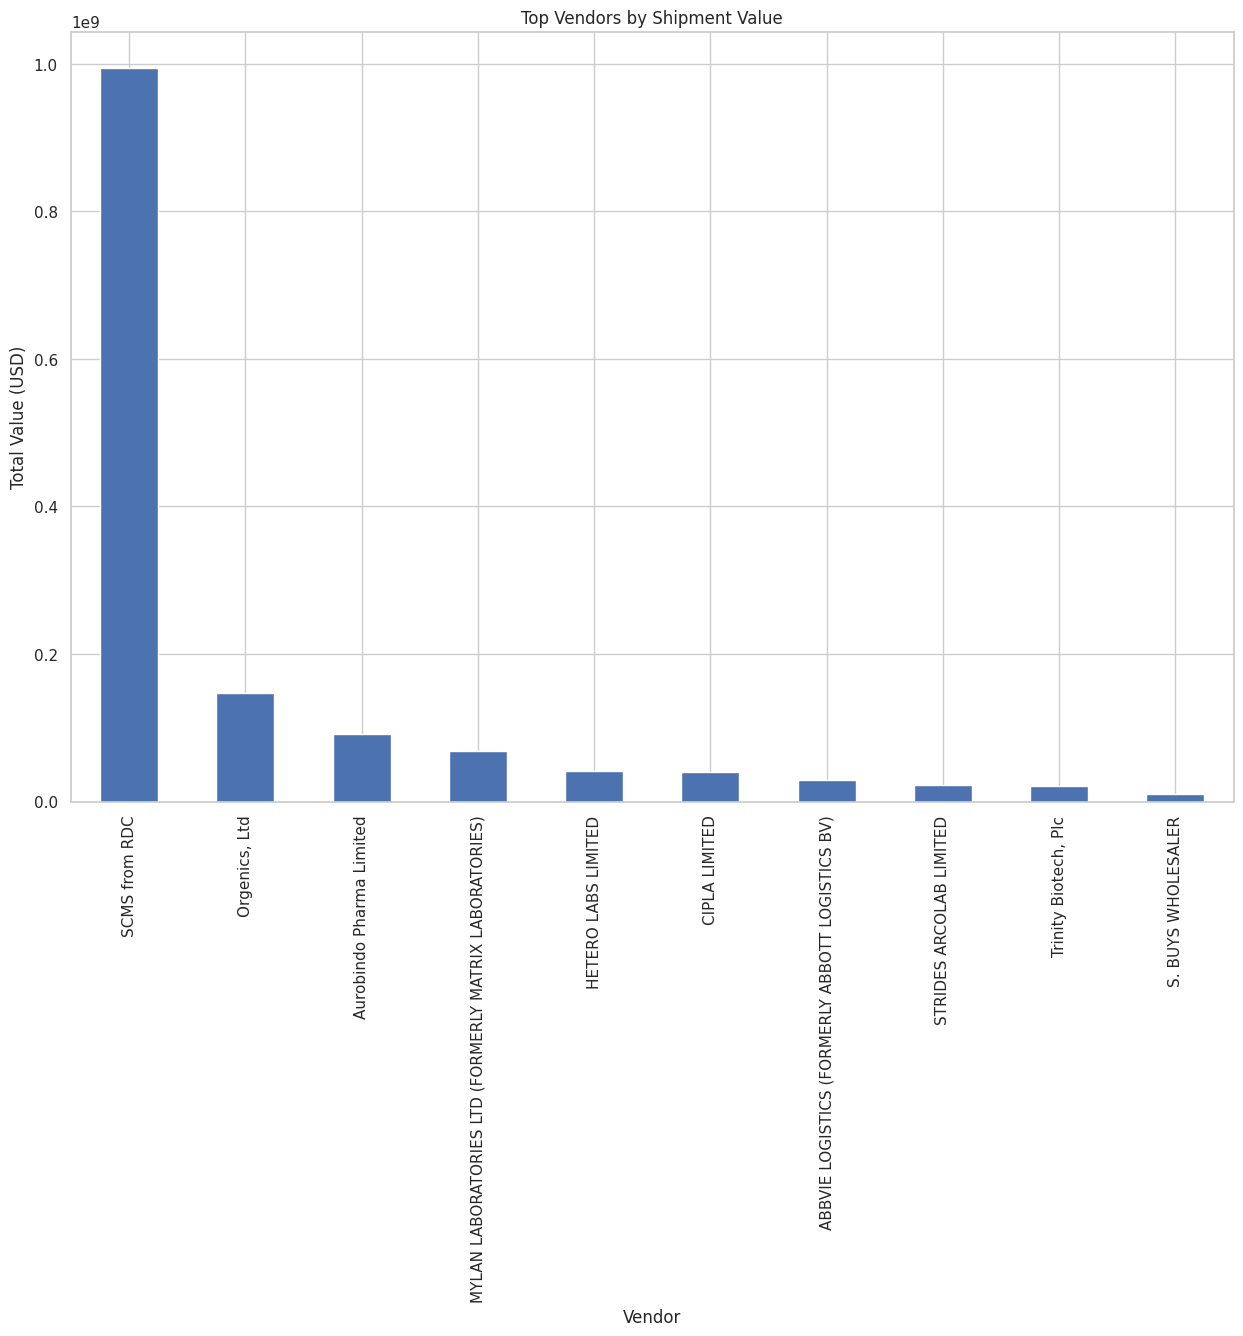

In [ ]:
# Top 10 Vendors by Total Shipment Value
plt.figure(figsize=(15,10))
ax=df.groupby('Vendor')['Line Item Value'].sum().sort_values(ascending=False).head(10).plot(kind='bar', title="Top Vendors by Shipment Value")
# here the y axis the values are in 100 million which is 0.1 , 0.2 for 200 million , 1.0 will be 1 billion USD
plt.ylabel("Total Value (USD)")
plt.xticks(rotation=90)
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart for comparison is best

##### 2. What is/are the insight(s) found from the chart?

Shows which company has the most shipment value , so it's SCMS from RDC currently has 1 Billion worth value

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

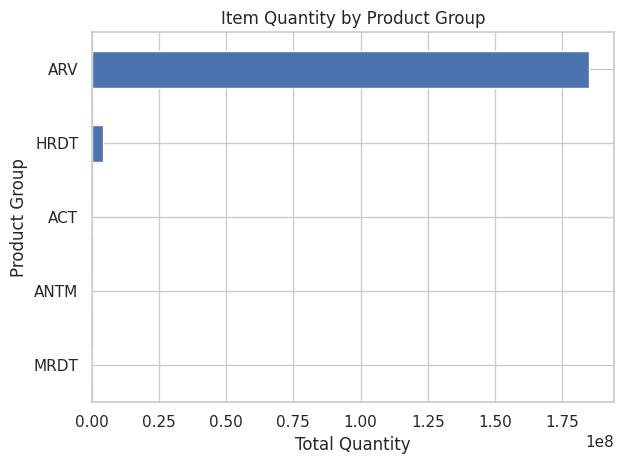

In [ ]:
# Item Quantity by Product Group
df.groupby('Product Group')['Line Item Quantity'].sum().sort_values().plot(kind='barh', title="Item Quantity by Product Group")
plt.xlabel("Total Quantity")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart best for categorical data , Product Groups in this case.

##### 2. What is/are the insight(s) found from the chart?

ARV is the mass produced product group , would be 80 million (quantity), then HRDT with 10 million (quantity)

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

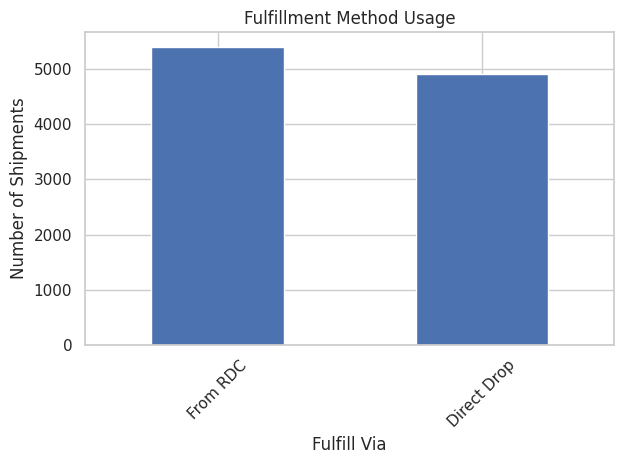

In [ ]:
# Shipments by Fulfillment Method
df['Fulfill Via'].value_counts().plot(kind='bar', title="Fulfillment Method Usage")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

 Bar chart shows the categorical data in a convenient way

##### 2. What is/are the insight(s) found from the chart?

Most deliveries that reach to the customer are

RDC - Regional Distribution Center
Direct Drop - Manufacturer to Customer , the retailer doesn't hold any products.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Both  options are frequently used , most would be RDC as its convenient for Customers and Manufacturer becuase of Faster Supply , customer satisfaction , and Better Inventory Management .

#### Chart - 13

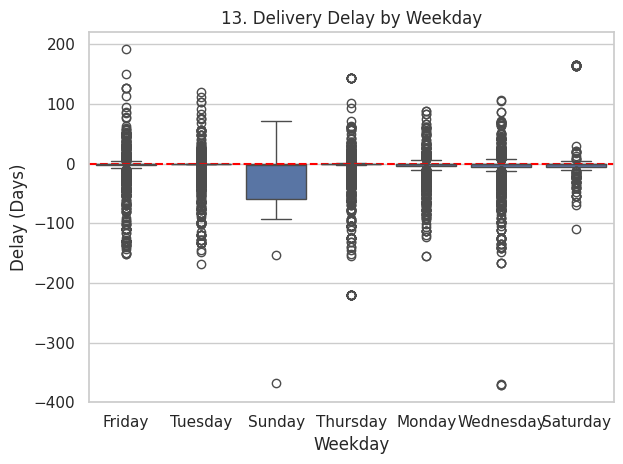

In [ ]:
# 13. Delivery Delays by Weekday
sns.boxplot(data=df, x='Weekday', y='Delay (Days)')
plt.title("13. Delivery Delay by Weekday")
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Boxplot shows the Distribution the Delay on which day of the week.

##### 2. What is/are the insight(s) found from the chart?

Most days of the week have delays , but weekends Saturday and sunday have less delays because of more Workforce , maybe overtime  people who partime job might be included into the workforce etc

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

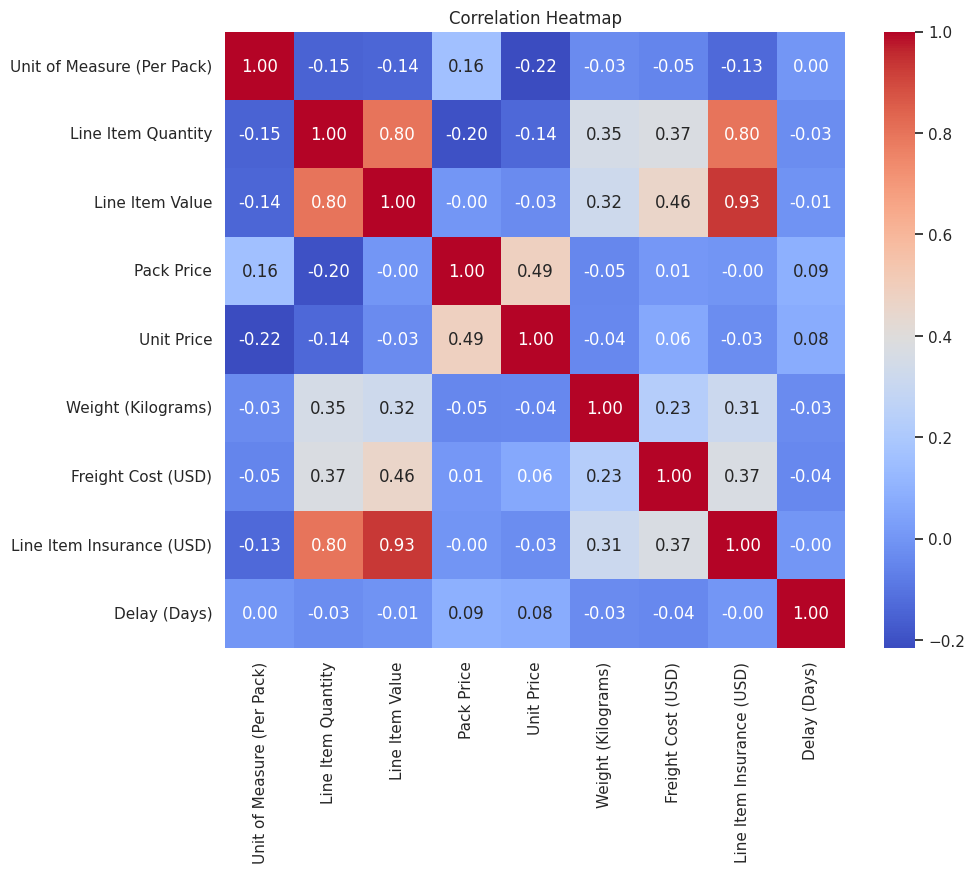

In [ ]:
# Correlation Heatmap visualization code
df_numeric=df.select_dtypes(include=['number'])
df_numeric=df_numeric.drop('ID',axis=1)
correlation_matrix=df_numeric.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

A Heatmap shows the correlation between variables

##### 2. What is/are the insight(s) found from the chart?

 In this case ID column is irrelevant , so removed it

Variable Pair | Correlation | Insight
--------------|-------------|---------
Line Item Quantity ↔ Line Item Value | 0.80 | More quantity leads to higher shipment value.
Line Item Value ↔ Line Item Insurance (USD) | 0.93 | Insurance cost scales directly with shipment value.
Line Item Quantity ↔ Line Item Insurance (USD) | 0.80 | Higher quantity also raises insurance cost.
Pack Price ↔ Unit Price | 0.49 | Pricing fields are moderately related — pack size affects cost/unit.
Weight ↔ Freight Cost (USD) | 0.23 | Heavier shipments have higher freight cost, but not strongly correlated.
Line Item Value ↔ Freight Cost (USD) | 0.46 | Higher-value shipments tend to use costlier shipping modes.
Delay (Days) ↔ Others | ~0.0 | Delay isn’t driven by quantity, cost, or weight — likely external causes.

#### Chart - 15 - Pair Plot

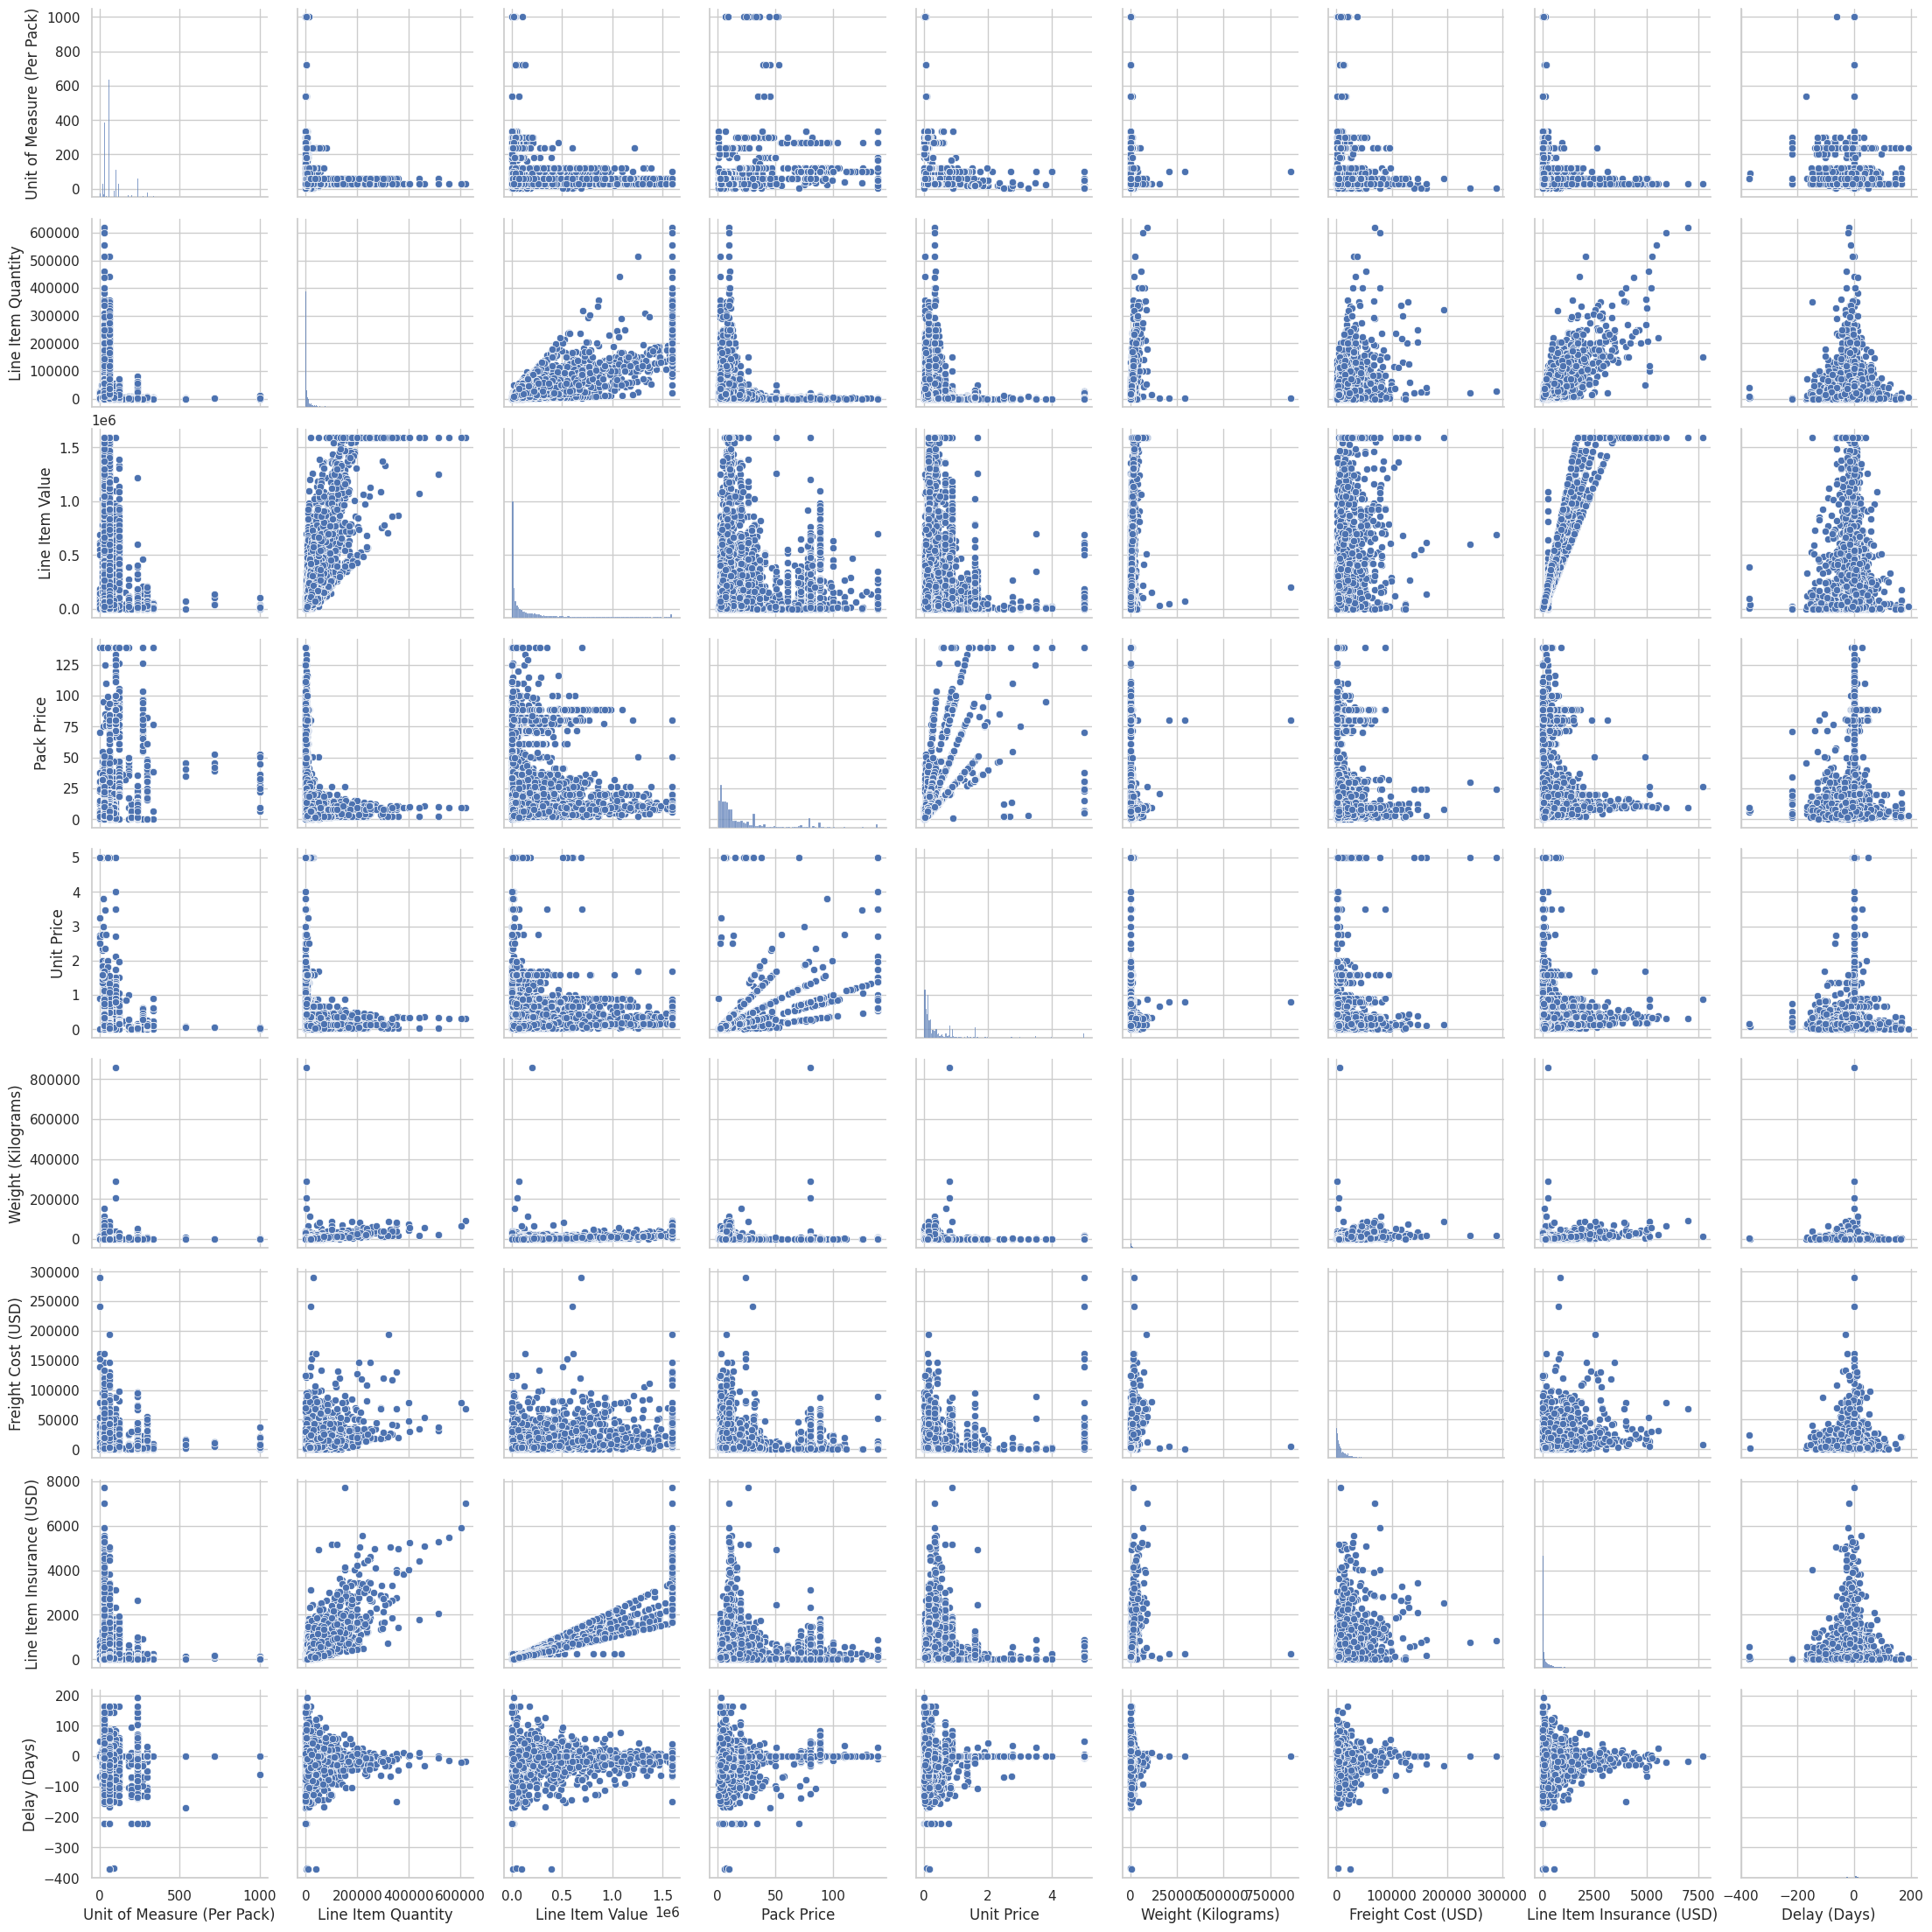

In [ ]:
# Pair Plot visualization code
sns.pairplot(df_numeric)
plt.show()

##### 1. Why did you pick the specific chart?

Good Alternative for finding Corelations in variables

##### 2. What is/are the insight(s) found from the chart?

Variable Pair | Visual Pattern | Insight
--------------|----------------|---------
Line Item Quantity ↔ Line Item Value | Clear upward trend | Value increases with quantity.
Line Item Value ↔ Line Item Insurance (USD) | Very tight linear cluster | Insurance is strongly tied to value.
Line Item Quantity ↔ Line Item Insurance (USD) | Strong linear trend | Quantity indirectly affects insurance.
Pack Price ↔ Unit Price | Moderate upward pattern | Logical connection between unit and pack pricing.
Weight ↔ Freight Cost | Loose upward trend | Freight cost rises with weight, but influenced by other factors too.
Line Item Value ↔ Freight Cost (USD) | Scattered upward trend | High-value goods often incur higher shipping costs.
Delay (Days) ↔ Others | No clear pattern | Delay appears unrelated to cost, weight, or quantity.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?


##**Data Cleaning and Preprocessing**:

Convert textual numerical values in Weight (Kilograms) and Freight Cost (USD) into usable float types.

Impute or address missing values in Shipment Mode, Dosage, and Line Item Insurance (USD).

##**Outlier Detection:**

Use boxplots and IQR analysis on Pack Price, Unit Price, Line Item Value, and Freight Cost (USD).

##**Delivery Performance Tracking:**

Calculate delays between Scheduled Delivery Date and Delivered to Client Date.

Visualize delivery lead times by country and vendor.

##**Cost Analysis:**

Correlate Freight Cost, Weight, and Shipment Mode to identify inefficiencies.

##**Actionable Dashboards:**

Provide executive summaries of cost-heavy routes, vendors with frequent delays, and top-performing delivery methods.



# **Conclusion**

Through the analysis of over 10,000 delivery records, the project highlights inefficiencies in delivery scheduling, missing cost data, and high variance in product pricing. Recommendations include improving vendor selection based on historic performance, addressing data entry gaps, and leveraging air shipments for high-priority orders. Effective visualization and metric tracking tools will aid FedEx and partners in strategic supply chain management.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***